In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc)
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("data.csv")

In [3]:
#Drop irrelevant columns
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)

In [4]:
#Encode target variable
df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])  # M=1, B=0

In [5]:
#Split features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [6]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

In [7]:
#Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
print("Before SMOTE:", y_train.value_counts())

Before SMOTE: diagnosis
0    239
1    142
Name: count, dtype: int64


In [10]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

In [11]:
print("After SMOTE:", np.bincount(y_train_resampled))

After SMOTE: [239 239]


In [12]:
roc_results = {}

In [13]:
# Model 1: Random Forest
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train_resampled, y_train_resampled)
ypred_rf = model_rf.predict(X_test)
yprob_rf = model_rf.predict_proba(X_test)[:, 1]

In [14]:
# Metrics and ROC
print("\nRandom Forest Metrics:\n", classification_report(y_test, ypred_rf))
fpr_rf, tpr_rf, _ = roc_curve(y_test, yprob_rf)
roc_results['Random Forest'] = (fpr_rf, tpr_rf, auc(fpr_rf, tpr_rf))


Random Forest Metrics:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       118
           1       1.00      0.93      0.96        70

    accuracy                           0.97       188
   macro avg       0.98      0.96      0.97       188
weighted avg       0.97      0.97      0.97       188



In [15]:
# Model 2: KNN
model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_resampled, y_train_resampled)
ypred_knn = model_knn.predict(X_test)
yprob_knn = model_knn.predict_proba(X_test)[:, 1]

In [16]:
print("\nKNN Metrics:\n", classification_report(y_test, ypred_knn))
fpr_knn, tpr_knn, _ = roc_curve(y_test, yprob_knn)
roc_results['KNN'] = (fpr_knn, tpr_knn, auc(fpr_knn, tpr_knn))


KNN Metrics:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       118
           1       0.98      0.91      0.95        70

    accuracy                           0.96       188
   macro avg       0.97      0.95      0.96       188
weighted avg       0.96      0.96      0.96       188



In [17]:
# Model 3: Logistic Regression
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_resampled, y_train_resampled)
ypred_lr = model_lr.predict(X_test)
yprob_lr = model_lr.predict_proba(X_test)[:, 1]

In [18]:
print("\nLogistic Regression Metrics:\n", classification_report(y_test, ypred_lr))
fpr_lr, tpr_lr, _ = roc_curve(y_test, yprob_lr)
roc_results['Logistic Regression'] = (fpr_lr, tpr_lr, auc(fpr_lr, tpr_lr))


Logistic Regression Metrics:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       118
           1       0.98      0.93      0.96        70

    accuracy                           0.97       188
   macro avg       0.97      0.96      0.97       188
weighted avg       0.97      0.97      0.97       188



In [19]:
# Model 4: Naive Bayes
model_nb = GaussianNB()
model_nb.fit(X_train_resampled, y_train_resampled)
ypred_nb = model_nb.predict(X_test)
yprob_nb = model_nb.predict_proba(X_test)[:, 1]

In [20]:
print("\nNaive Bayes Metrics:\n", classification_report(y_test, ypred_nb))
fpr_nb, tpr_nb, _ = roc_curve(y_test, yprob_nb)
roc_results['Naive Bayes'] = (fpr_nb, tpr_nb, auc(fpr_nb, tpr_nb))


Naive Bayes Metrics:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96       118
           1       0.98      0.86      0.92        70

    accuracy                           0.94       188
   macro avg       0.95      0.92      0.94       188
weighted avg       0.94      0.94      0.94       188



In [21]:
# Plot Confusion Matrices
models = {
    "Random Forest": ypred_rf,
    "KNN": ypred_knn,
    "Logistic Regression": ypred_lr,
    "Naive Bayes": ypred_nb
}

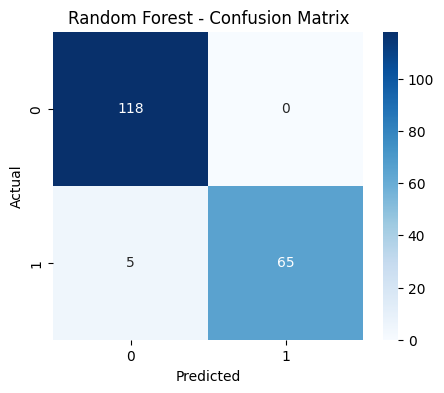

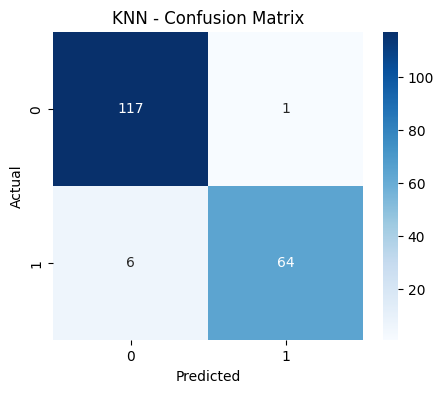

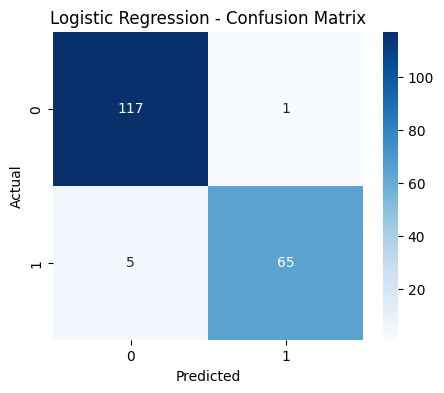

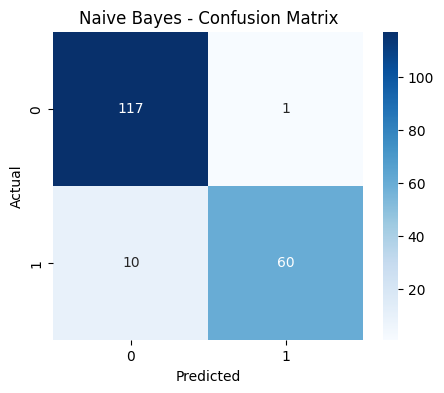

In [22]:
for name, preds in models.items():
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

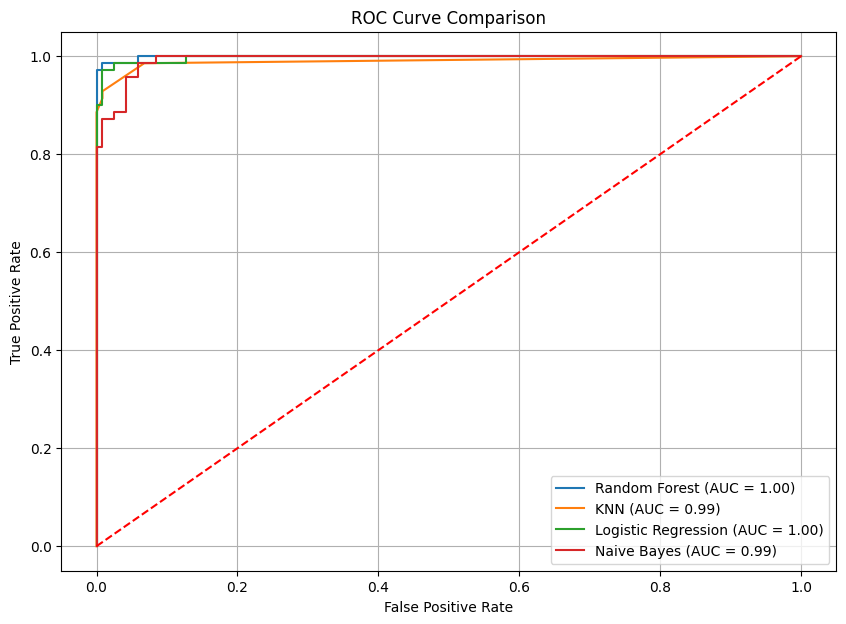

In [23]:
# Plot ROC Curves
plt.figure(figsize=(10, 7))
for name, (fpr, tpr, auc_score) in roc_results.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.2f})")
plt.plot([0, 1], [0, 1], 'r--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [30]:
results = []

In [26]:
# Model names and their prediction/ROC curve variables
model_metrics = {
    'Random Forest':      (ypred_rf, fpr_rf, tpr_rf),
    'KNN':                (ypred_knn, fpr_knn, tpr_knn),
    'Logistic Regression':(ypred_lr, fpr_lr, tpr_lr),
    'Naive Bayes':        (ypred_nb, fpr_nb, tpr_nb)
}

In [27]:
# Evaluate all models
for name, (ypred, fpr, tpr) in model_metrics.items():
    acc = accuracy_score(y_test, ypred)
    prec = precision_score(y_test, ypred)
    rec = recall_score(y_test, ypred)
    f1 = f1_score(y_test, ypred)
    auc_score = auc(fpr, tpr)  # ← using imported 'auc' from roc_curve

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'AUC': auc_score
    })

In [28]:
results_df = pd.DataFrame(results).sort_values(by=['AUC', 'F1 Score'], ascending=False)

In [29]:
print("\n📊 Model Performance Comparison:")
print(results_df)


📊 Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score       AUC
0        Random Forest  0.973404   1.000000  0.928571  0.962963  0.999031
4        Random Forest  0.973404   1.000000  0.928571  0.962963  0.999031
2  Logistic Regression  0.968085   0.984848  0.928571  0.955882  0.997215
6  Logistic Regression  0.968085   0.984848  0.928571  0.955882  0.997215
3          Naive Bayes  0.941489   0.983607  0.857143  0.916031  0.993220
7          Naive Bayes  0.941489   0.983607  0.857143  0.916031  0.993220
1                  KNN  0.962766   0.984615  0.914286  0.948148  0.989952
5                  KNN  0.962766   0.984615  0.914286  0.948148  0.989952


In [31]:
# Show the best model
best_model = results_df.iloc[0]
print(f"\n🏆 Best Model: {best_model['Model']}")
print(f" - AUC: {best_model['AUC']:.2f}")
print(f" - F1 Score: {best_model['F1 Score']:.2f}")
print(f" - Accuracy: {best_model['Accuracy']:.2f}")


🏆 Best Model: Random Forest
 - AUC: 1.00
 - F1 Score: 0.96
 - Accuracy: 0.97
